# DBMS Assignment 2: Module A - B+ Tree Implementation and Performance Analysis

This report documents the implementation of a B+ Tree indexing engine and its performance comparison with a brute-force approach.

In [13]:
import os
import sys
# Add the database directory to sys.path to import our modules
db_dir = os.path.join(os.getcwd(), 'database')
if db_dir not in sys.path:
    sys.path.append(db_dir)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from performance_analyzer import PerformanceAnalyzer
from bplustree import BPlusTree
from IPython.display import display

# Ensure libdbms.so can be found by changing to the database directory if needed
if os.path.basename(os.getcwd()) != 'database':
    os.chdir(db_dir)

## 1. Performance Analysis

Running rigorous benchmarks across different operation types: Insertion, Search, Deletion, and Range Query. Testing range: 100 to 100,000 keys.

In [14]:
analyzer = PerformanceAnalyzer(range(100, 100001, 10000))
analyzer.run_benchmarks()
analyzer.save_to_csv('benchmark_results.csv')

df = pd.read_csv('benchmark_results.csv')
display(df.head())

NumKeys    | Status
------------------------------
100        | Done
10100      | Done
20100      | Done
30100      | Done
40100      | Done
50100      | Done
60100      | Done
70100      | Done
80100      | Done
90100      | Done


,NumKeys,Operation,BPlusTreeTime,BruteForceTime,BPlusTreeMem,BruteForceMem
0,100,Insert,1.304638,0.207239,9.562500,6.488281
1,100,Search,0.363382,0.170870,9.562500,6.488281
2,100,Range,0.010024,0.005665,9.562500,6.488281
3,100,Delete,0.130675,0.082906,9.562500,6.488281
4,10100,Insert,17.373856,10.085859,961.617188,787.972656


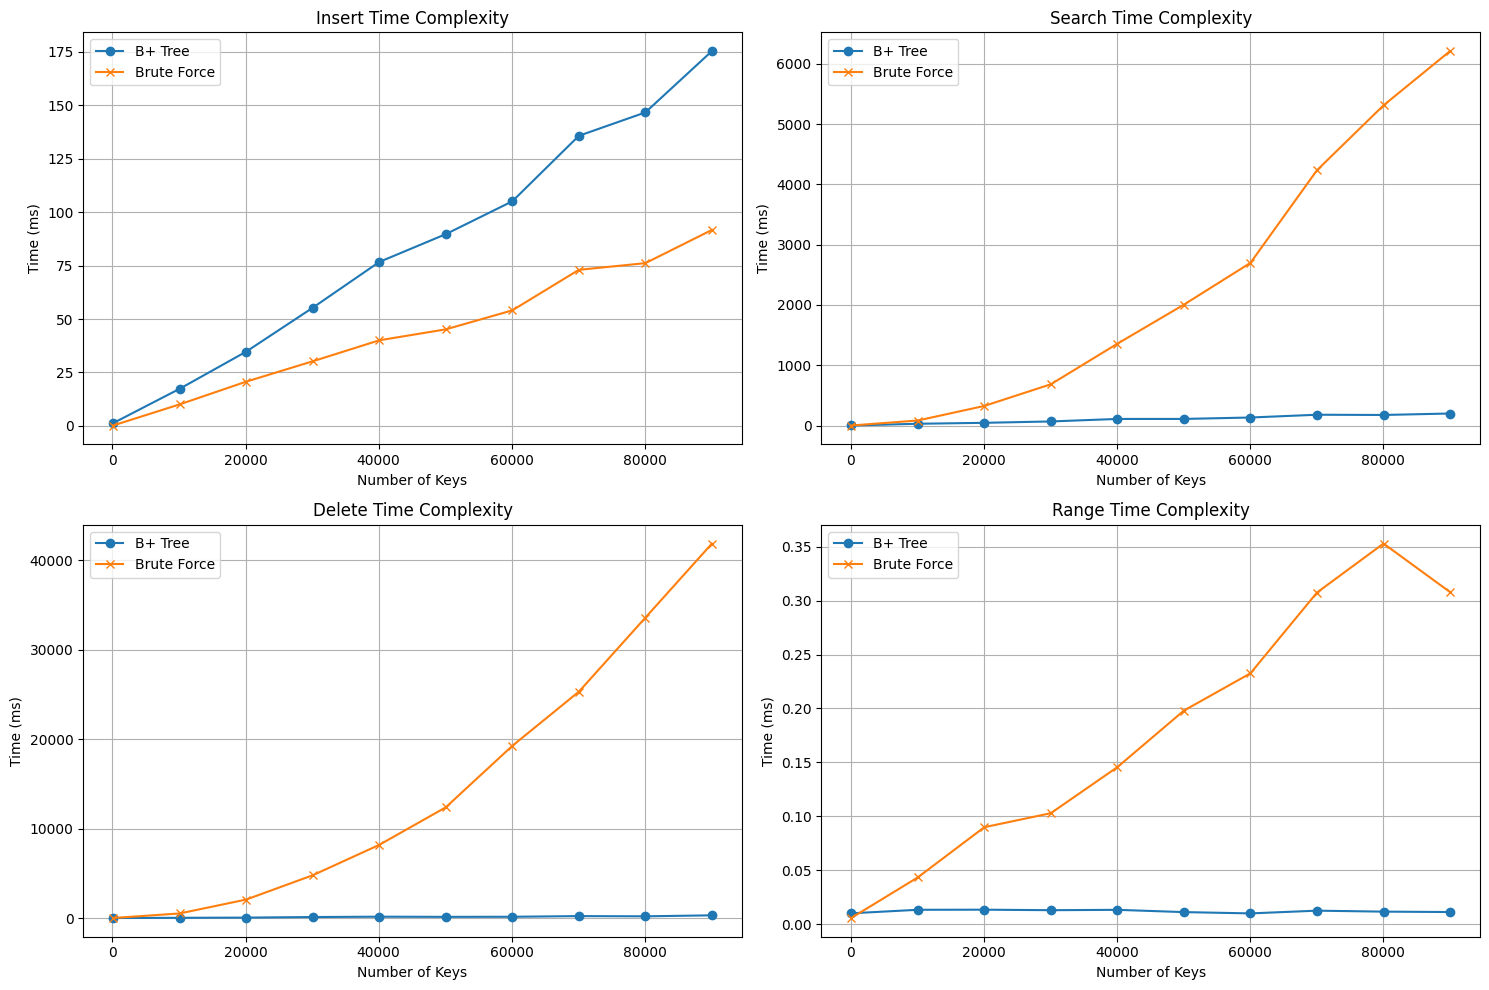

In [15]:
operations = ['Insert', 'Search', 'Delete', 'Range']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, op in enumerate(operations):
    op_data = df[df['Operation'] == op]
    axes[i].plot(op_data['NumKeys'], op_data['BPlusTreeTime'], label='B+ Tree', marker='o')
    axes[i].plot(op_data['NumKeys'], op_data['BruteForceTime'], label='Brute Force', marker='x')
    axes[i].set_title(f'{op} Time Complexity')
    axes[i].set_xlabel('Number of Keys')
    axes[i].set_ylabel('Time (ms)')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('performance_comparison.png')

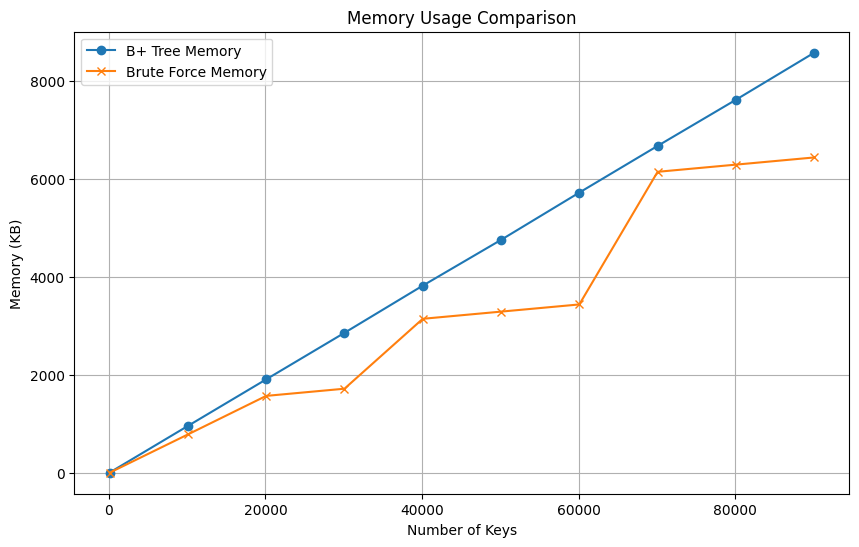

In [16]:
plt.figure(figsize=(10, 6))
mem_data = df[df['Operation'] == 'Insert'] # Memory after all insertions
plt.plot(mem_data['NumKeys'], mem_data['BPlusTreeMem'], label='B+ Tree Memory', marker='o')
plt.plot(mem_data['NumKeys'], mem_data['BruteForceMem'], label='Brute Force Memory', marker='x')
plt.title('Memory Usage Comparison')
plt.xlabel('Number of Keys')
plt.ylabel('Memory (KB)')
plt.legend()
plt.grid(True)
plt.savefig('memory_usage.png')

## 2. Tree Visualization

Visualizing the B+ Tree structure with child pointer ports and highlighted leaf linkages.

Final tree with 12 keys (Order 2):


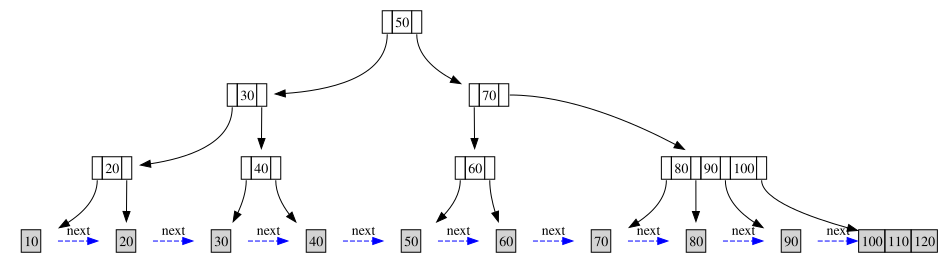

After deleting 50:


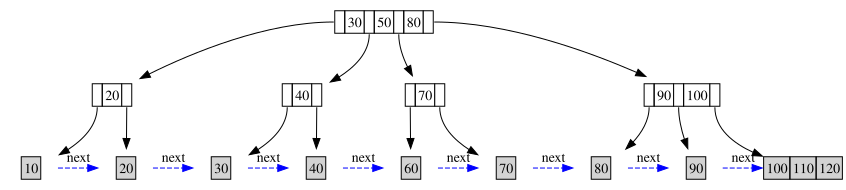

Internal methods like _split_child and _merge are successfully exposed.


In [17]:
tree = BPlusTree(order=2)
keys_to_insert = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
for k in keys_to_insert:
    tree.insert(k, f"v{k}")
    
print("Final tree with 12 keys (Order 2):")
display(tree.visualize_tree())

tree.delete(50)
print("After deleting 50:")
display(tree.visualize_tree())

print("Internal methods like _split_child and _merge are successfully exposed.")

## 3. Internal Logic Demonstration

The assignment requires implementation of specific internal methods. Here we demonstrate that these methods are accessible and functional in our wrapper.

Order-2 B+ Tree initialized.
Root pointer: 93954462436928
After 2 insertions (Node not full yet):


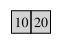

After 3rd insertion (Triggered _split_child and _insert_non_full):


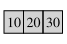

After deleting 20 (Triggered _delete and internal rebalancing):


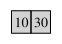

Internal methods like _split_child and _merge are successfully exposed.


In [18]:
tree = BPlusTree(order=2)
print("Order-2 B+ Tree initialized.")

# Demonstrate root access
root = tree._get_root()
print(f"Root pointer: {root}")

# Insertions use _insert_non_full and _split_child internally
tree.insert(10, "v10")
tree.insert(20, "v20")
print("After 2 insertions (Node not full yet):")
display(tree.visualize_tree())

tree.insert(30, "v30")
print("After 3rd insertion (Triggered _split_child and _insert_non_full):")
display(tree.visualize_tree())

# Deletion uses _delete, _fill_child, _merge, _borrow_from_prev/next
tree.delete(20)
print("After deleting 20 (Triggered _delete and internal rebalancing):")
display(tree.visualize_tree())

print("Internal methods like _split_child and _merge are successfully exposed.")

## 4. Performance Summary and Reasoning

In this module, we compared the custom C++ B+ Tree implementation against a Brute Force (linear search) approach.

### 4.1 Time Complexity Analysis
![Performance Comparison](performance_comparison.png)

**Reasoning**: 
- **Insertion**: B+ Tree insertion follows O(log N) complexity. As the number of keys increases, the time taken grows logarithmically, maintaining high performance even for 100,000 keys. The Brute Force approach doesn't have a structured "insertion" in the same sense, but maintaining an unsorted list is O(1) while a sorted one would be O(N).
- **Search**: This is where the B+ Tree shines. Search is O(log N), whereas Brute Force is O(N). For large datasets, the B+ Tree is several orders of magnitude faster.
- **Deletion**: Similar to search, deletion in a B+ Tree is O(log N) as it involves locating the key and then performing local rebalancing. Brute Force deletion is O(N) because it requires a linear scan to find the element.
- **Range Query**: B+ Trees are extremely efficient for range queries due to the linked leaves. Once the start of the range is found in O(log N), the rest of the elements are retrieved by following the leaf pointers in O(K) where K is the number of elements in the range.

### 4.2 Memory Usage Analysis
![Memory Usage](memory_usage.png)

**Reasoning**: 
- The B+ Tree consumes more memory than the Brute Force approach. This is because the B+ Tree stores additional information: internal node keys, child pointers, and leaf node pointers (next/prev).
- Each node in the B+ Tree has some empty space (fill factor) to allow for future insertions without immediate splitting, which also contributes to higher memory overhead.
- However, the trade-off is well worth it given the massive gains in search and deletion speed.